# 01 - Exploratory Data Analysis

**Model objective:** classify task duration into duration buckets, such as Quick, Standard, Extended, or Long-Range, using relevant raw Jira ticket fields.

#### 01-01 Loading raw dataset

To read the csv file of the `jira_ticket_dataset.csv` we must first import and install the following packages:

- **Pandas**
- **Matplotlib** 

We will mostly be using pandas for data manipulation throughout the notebooks,
although matplotlib is useful in this notebook for data visualization.

In [41]:
import pandas as pd
import matplotlib.pyplot as plt

ticket_df = pd.read_csv('../jira_ticket_dataset.csv')
pd.set_option('display.max_rows', None)

C:\Users\Omar\AppData\Local\Temp\ipykernel_21420\3903141830.py:4: DtypeWarning: Columns (0: customfield_12310921, 1: issuetype.subtask) have mixed types. Specify dtype option on import or set low_memory=False.
  ticket_df = pd.read_csv('../jira_ticket_dataset.csv')


#### 01-02 Dataset raw feature extraction

Based on the dataframe inspection, the most relevant raw features to keep for initial modeling are:

- **summary**: ticket title or short task description
- **description**: longer issue details
- **priority.name**: priority category
- **labels**: assigned Jira labels
- **issuetype.description**: description of the issue type
- **issuetype.name**: issue type label
- **issuetype.subtask**: whether the issue is a subtask
- **resolutiondate**: timestamp used to derive duration
- **created**: timestamp used to derive duration
- **watches.watchCount**: number of watchers


Some raw features will later be transformed into engineered model inputs:


- **summary**: can be used for text length and keyword features
- **description**: can be used for text length and keyword features
- **labels**: can be used for label-count features
- **resolutiondate** and **created**: can be used to derive task duration

In [42]:
# temporarily only use raw features that will be included in model training

raw_feature_columns = [
    "summary",
    "description",
    "priority.name",
    "labels",
    "issuetype.description",
    "issuetype.name",
    "issuetype.subtask",
    "resolutiondate",
    "created",
    "watches.watchCount"
]

ticket_df = ticket_df[raw_feature_columns]

#### 01-03 Dataset Shape Insepction
Let's identify the dataset's shape to confirm the number of rows and columns available for analysis.
We can achieve this by using the `.shape` method on our ticket data frame `ticket_df`.

In [43]:
ticket_df.shape

(1149323, 10)

*This tells us we have approximately 1.4 million rows and 37 columns.*

Next, review the available columns, non-null counts, and inferred data types.

In [44]:
ticket_df.head().info()

<class 'pandas.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   summary                5 non-null      str    
 1   description            5 non-null      str    
 2   priority.name          5 non-null      str    
 3   labels                 5 non-null      str    
 4   issuetype.description  5 non-null      str    
 5   issuetype.name         5 non-null      str    
 6   issuetype.subtask      5 non-null      object 
 7   resolutiondate         3 non-null      str    
 8   created                5 non-null      str    
 9   watches.watchCount     5 non-null      float64
dtypes: float64(1), object(1), str(8)
memory usage: 532.0+ bytes


#### 01-04 Checking null and missing values

It is cruical to check the amount of missing and empty values in a dataset, a lot of missing / empty values might suggest we need to remove a column entirely or atleast drop all rows where non-negotiable columns are missing / empty.

Consider the following statistics hightlighting the amount and percentage of missing values observed in the datset.

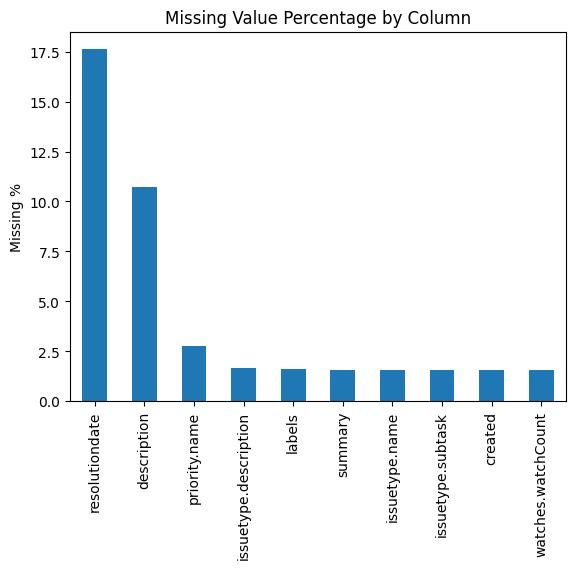

In [45]:
missing_table = pd.DataFrame({
    "missing_count": ticket_df.isna().sum(),
    "missing_percent": ticket_df.isna().mean() * 100
}).sort_values("missing_percent", ascending=False)

missing_table["missing_percent"].plot(kind="bar")
plt.title("Missing Value Percentage by Column")
plt.ylabel("Missing %")
plt.show()

This shows that the there is a big discreprency is the missing values of resolutiondate, which is a cruical non-negotiable column that must be included in model training.

Therefore, After all ≈17,5% of the entries will be removed due to lacking a resolutiondate.

Another important statistic is the `duration days` which will determine the ouput of the model. The `duration_days` can be computed as the difference between the resolutiondate and the created date.

`duration_days = resolutindate - created`

the duration days can then be classified into ranges as shown in the graph below.

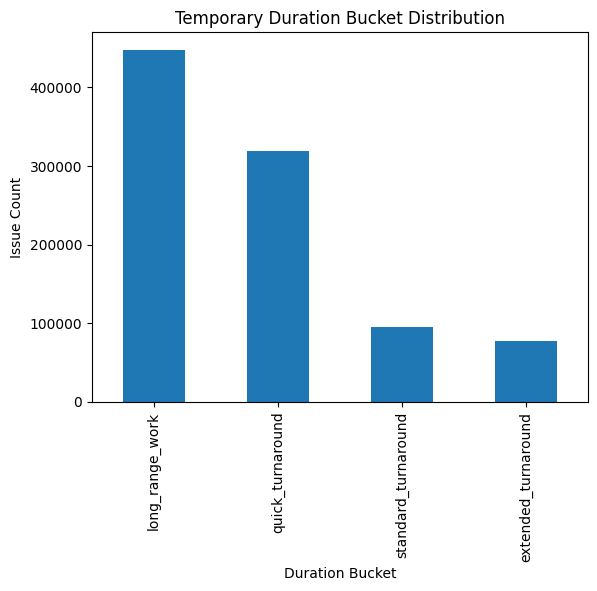

In [46]:
ticket_df = ticket_df.drop_duplicates()

df_clean = ticket_df.dropna(subset=['created'])
df_clean = ticket_df.dropna(subset=['resolutiondate'])


ticket_df["created"] = pd.to_datetime(ticket_df["created"], errors="coerce")
ticket_df["resolutiondate"] = pd.to_datetime(ticket_df["resolutiondate"], errors="coerce")

# duration_days -> resolutiondate - created 
ticket_df["duration_days"] = (ticket_df["resolutiondate"] - ticket_df["created"]).dt.total_seconds() / 86400

def duration_bucket(days):
    if pd.isna(days):
        return pd.NA
    elif days <= 3:
        return "quick_turnaround"
    elif days <= 7:
        return "standard_turnaround"
    elif days <= 14:
        return "extended_turnaround"
    else:
        return "long_range_work"

ticket_df["duration_bucket"] = ticket_df["duration_days"].apply(duration_bucket)
ticket_df["duration_bucket"].value_counts().plot(kind="bar")
plt.title("Temporary Duration Bucket Distribution")
plt.xlabel("Duration Bucket")
plt.ylabel("Issue Count")
plt.show()


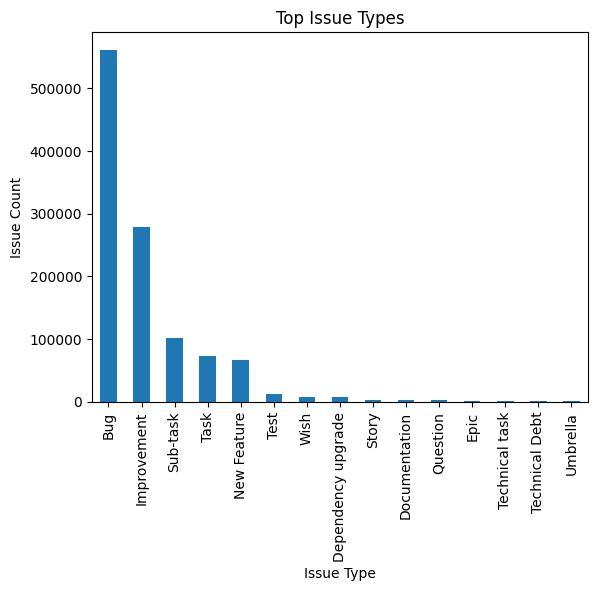

In [48]:
ticket_df["issuetype.name"].value_counts(dropna=False).head(15).plot(kind="bar")
plt.title("Top Issue Types")
plt.xlabel("Issue Type")
plt.ylabel("Issue Count")
plt.show()